<a href="https://colab.research.google.com/github/edwardmoreno18/DeepLearning/blob/main/redes_neuronales_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
  # IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# NumPy y Pandas se utilizan para manipular datos y construir tablas de resultados.
# Matplotlib permite generar gráficas para analizar el entrenamiento de los modelos.
# TensorFlow/Keras se utiliza para construir, entrenar y evaluar redes neuronales.
# Scikit-learn aporta la división de datos y las métricas de clasificación.
# Se fija una semilla para intentar que los experimentos sean reproducibles.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [2]:
# CARGA DEL CONJUNTO DE DATOS MNIST
# MNIST contiene imágenes de dígitos escritos a mano del 0 al 9.
# Se separan los datos originales de entrenamiento y de prueba.
# x contiene las imágenes y y contiene la etiqueta numérica de cada imagen.
# Las dimensiones permiten comprobar que las imágenes son de 28 x 28 píxeles.

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train original:", x_train_full.shape, y_train_full.shape)
print("Test:", x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train original: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [3]:
# DIVISIÓN DEL CONJUNTO DE ENTRENAMIENTO
# Se reserva el 20 % de los datos originales de entrenamiento para validación (dev).
# El parámetro stratify mantiene una distribución de clases similar en ambos conjuntos.
# random_state utiliza la semilla definida anteriormente para obtener una partición reproducible.
# El conjunto de prueba permanece separado y no participa en el entrenamiento.

x_train, x_dev, y_train, y_dev = train_test_split(

    x_train_full, y_train_full,

    test_size=0.20,

    random_state=SEED,

    stratify=y_train_full

)



print("Train:", x_train.shape, y_train.shape)

print("Dev:", x_dev.shape, y_dev.shape)

print("Test:", x_test.shape, y_test.shape)

Train: (48000, 28, 28) (48000,)
Dev: (12000, 28, 28) (12000,)
Test: (10000, 28, 28) (10000,)


In [4]:
# NORMALIZACIÓN DE LAS IMÁGENES
# Los píxeles de MNIST están originalmente entre 0 y 255.
# Se convierten a float32 y se dividen entre 255 para llevarlos al rango [0, 1].
# La normalización facilita el entrenamiento de la red neuronal y mejora su estabilidad numérica.

x_train = x_train.astype("float32") / 255.0

x_dev   = x_dev.astype("float32") / 255.0

x_test  = x_test.astype("float32") / 255.0



print("Rango train:", x_train.min(), x_train.max())

Rango train: 0.0 1.0


In [5]:
# ANÁLISIS DE LA DISTRIBUCIÓN DE CLASES
# Esta función cuenta cuántos ejemplos existen de cada dígito entre 0 y 9.
# np.bincount calcula las frecuencias y se fuerza a tener las 10 clases.
# Después se calcula el porcentaje que representa cada clase.
# Finalmente se construye una tabla para revisar si los conjuntos están balanceados.

def distribucion_clases(y, nombre):

    conteos = np.bincount(y, minlength=10)

    porcentajes = conteos / len(y) * 100

    tabla = pd.DataFrame({

        "digito": np.arange(10),

        "cantidad": conteos,

        "porcentaje": np.round(porcentajes, 2)

    })

    print("\n", nombre)

    display(tabla)

    return tabla



dist_train = distribucion_clases(y_train, "TRAIN")

dist_dev   = distribucion_clases(y_dev, "DEV")

dist_test  = distribucion_clases(y_test, "TEST")


 TRAIN


,digito,cantidad,porcentaje
0,0,4738,9.87
1,1,5394,11.24
2,2,4766,9.93
3,3,4905,10.22
4,4,4674,9.74
5,5,4337,9.04
6,6,4734,9.86
7,7,5012,10.44
8,8,4681,9.75
9,9,4759,9.91



 DEV


,digito,cantidad,porcentaje
0,0,1185,9.88
1,1,1348,11.23
2,2,1192,9.93
3,3,1226,10.22
4,4,1168,9.73
5,5,1084,9.03
6,6,1184,9.87
7,7,1253,10.44
8,8,1170,9.75
9,9,1190,9.92



 TEST


,digito,cantidad,porcentaje
0,0,980,9.80
1,1,1135,11.35
2,2,1032,10.32
3,3,1010,10.10
4,4,982,9.82
5,5,892,8.92
6,6,958,9.58
7,7,1028,10.28
8,8,974,9.74
9,9,1009,10.09


In [6]:
# MODELO BASELINE
# Se define una red neuronal sencilla como punto de referencia.
# Input recibe imágenes de 28 x 28 píxeles.
# Flatten convierte cada imagen en un vector de 784 características.
# Dense con ReLU crea una capa oculta de 128 neuronas.
# La capa final tiene 10 neuronas y Softmax genera una probabilidad para cada dígito.
# Adam se utiliza como optimizador por defecto cuando no se especifica otro.
# sparse_categorical_crossentropy es adecuada porque las etiquetas son enteros 0-9.

def crear_modelo_baseline(units=128, optimizer=None):

    modelo = keras.Sequential([

        layers.Input(shape=(28, 28)),

        layers.Flatten(),

        layers.Dense(units, activation="relu"),

        layers.Dense(10, activation="softmax")

    ])



    if optimizer is None:

        optimizer = keras.optimizers.Adam(learning_rate=0.001)



    modelo.compile(

        optimizer=optimizer,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return modelo



modelo_base = crear_modelo_baseline()

modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ENTRENAMIENTO DEL MODELO BASELINE
# Se entrena la red con los datos de entrenamiento.
# validation_data permite medir el comportamiento sobre el conjunto de desarrollo.
# Se utilizan 5 épocas y lotes de 64 imágenes.
# El objeto hist_base guarda la evolución de loss y accuracy durante el entrenamiento.

hist_base = modelo_base.fit(

    x_train, y_train,

    validation_data=(x_dev, y_dev),

    epochs=5,

    batch_size=64,

    verbose=1

)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9079 - loss: 0.3321 - val_accuracy: 0.9427 - val_loss: 0.1966
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9541 - loss: 0.1564 - val_accuracy: 0.9573 - val_loss: 0.1501
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9686 - loss: 0.1099 - val_accuracy: 0.9617 - val_loss: 0.1291
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9761 - loss: 0.0829 - val_accuracy: 0.9664 - val_loss: 0.1151
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9816 - loss: 0.0646 - val_accuracy: 0.9673 - val_loss: 0.1100


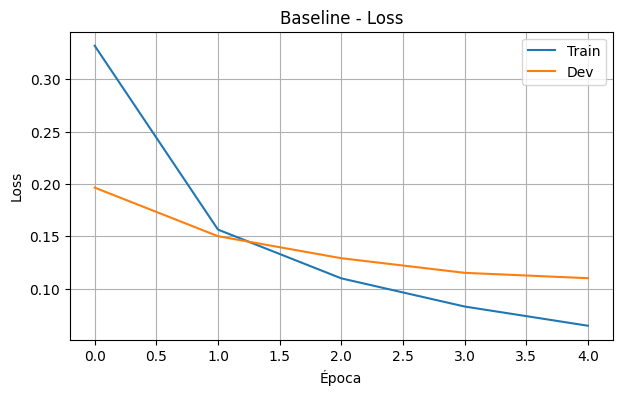

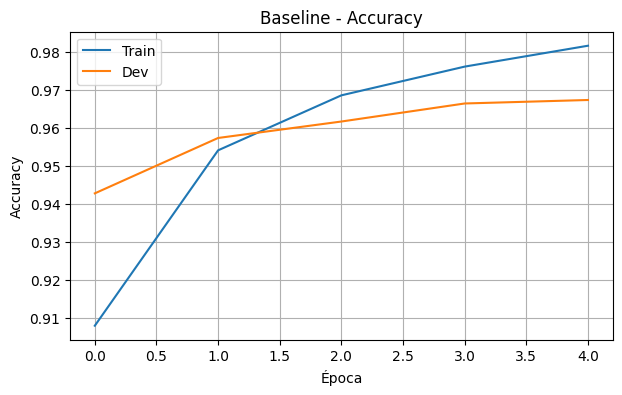

In [8]:
# VISUALIZACIÓN DEL ENTRENAMIENTO BASELINE
# La primera gráfica muestra la evolución de la pérdida (loss) en entrenamiento y validación.
# La segunda gráfica muestra la evolución de accuracy en entrenamiento y validación.
# Comparar ambas curvas ayuda a detectar aprendizaje insuficiente o sobreajuste.

plt.figure(figsize=(7, 4))

plt.plot(hist_base.history["loss"], label="Train")

plt.plot(hist_base.history["val_loss"], label="Dev")

plt.xlabel("Época")

plt.ylabel("Loss")

plt.title("Baseline - Loss")

plt.legend()

plt.grid(True)

plt.show()



plt.figure(figsize=(7, 4))

plt.plot(hist_base.history["accuracy"], label="Train")

plt.plot(hist_base.history["val_accuracy"], label="Dev")

plt.xlabel("Época")

plt.ylabel("Accuracy")

plt.title("Baseline - Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [9]:
# FUNCIÓN PARA CREAR MODELOS DE EXPERIMENTO
# Esta función construye la misma arquitectura del baseline,
# pero recibe el optimizador como parámetro para poder comparar alternativas.
# De esta forma, solamente cambia el optimizador y el resto de condiciones se mantiene controlado.

def crear_modelo_experimento(optimizador, units=128):

    modelo = keras.Sequential([

        layers.Input(shape=(28, 28)),

        layers.Flatten(),

        layers.Dense(units, activation="relu"),

        layers.Dense(10, activation="softmax")

    ])

    modelo.compile(

        optimizer=optimizador,

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return modelo

In [10]:
# COMPARACIÓN DE OPTIMIZADORES
# Se crean fábricas para generar tres optimizadores: SGD con momentum, RMSprop y Adam.
# Cada modelo se entrena por separado con las mismas condiciones.
# clear_session libera el estado anterior de Keras y la semilla vuelve a fijarse.
# Se almacenan las historias de entrenamiento y las métricas finales en una tabla.
# Esto permite comparar accuracy de entrenamiento, accuracy de validación y validation loss.

fabricas_optimizadores = {

    "SGD_momentum": lambda: keras.optimizers.SGD(

        learning_rate=0.01, momentum=0.9

    ),

    "RMSprop": lambda: keras.optimizers.RMSprop(

        learning_rate=0.001

    ),

    "Adam": lambda: keras.optimizers.Adam(

        learning_rate=0.001

    )

}



resultados_opt = []

historias_opt = {}



for nombre, fabrica in fabricas_optimizadores.items():

    keras.backend.clear_session()

    tf.random.set_seed(SEED)



    modelo = crear_modelo_experimento(fabrica())



    historia = modelo.fit(

        x_train, y_train,

        validation_data=(x_dev, y_dev),

        epochs=5,

        batch_size=64,

        verbose=0

    )



    historias_opt[nombre] = historia

    resultados_opt.append({

        "optimizador": nombre,

        "train_accuracy": historia.history["accuracy"][-1],

        "dev_accuracy": historia.history["val_accuracy"][-1],

        "dev_loss": historia.history["val_loss"][-1]

    })



tabla_opt = pd.DataFrame(resultados_opt)

display(tabla_opt)



,optimizador,train_accuracy,dev_accuracy,dev_loss
0,SGD_momentum,0.966833,0.959000,0.142435
1,RMSprop,0.980542,0.966750,0.112646
2,Adam,0.982604,0.966167,0.116951


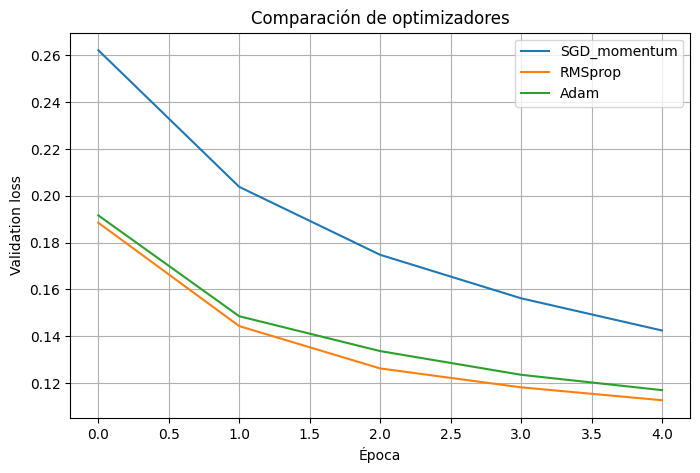

In [11]:
# GRÁFICA COMPARATIVA DE OPTIMIZADORES
# Se dibuja la validation loss de cada optimizador a lo largo de las épocas.
# Una curva menor indica menor pérdida sobre el conjunto de desarrollo.
# La gráfica permite observar diferencias en velocidad de aprendizaje y estabilidad.

plt.figure(figsize=(8, 5))

for nombre, historia in historias_opt.items():

    plt.plot(historia.history["val_loss"], label=nombre)



plt.xlabel("Época")

plt.ylabel("Validation loss")

plt.title("Comparación de optimizadores")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
# EXPERIMENTO CON LEARNING RATE
# Se prueban tres tasas de aprendizaje para Adam.
# Cada valor se evalúa en un modelo nuevo para mantener independientes los experimentos.
# Se registran las métricas finales para determinar qué tasa funciona mejor bajo estas condiciones.

learning_rates = [0.0001, 0.001, 0.01]

resultados_lr = []



for lr in learning_rates:

    keras.backend.clear_session()

    tf.random.set_seed(SEED)



    modelo = crear_modelo_experimento(

        keras.optimizers.Adam(learning_rate=lr)

    )



    historia = modelo.fit(

        x_train, y_train,

        validation_data=(x_dev, y_dev),

        epochs=3,

        batch_size=64,

        verbose=0

    )



    resultados_lr.append({

        "learning_rate": lr,

        "train_accuracy": historia.history["accuracy"][-1],

        "dev_accuracy": historia.history["val_accuracy"][-1],

        "dev_loss": historia.history["val_loss"][-1]

    })



display(pd.DataFrame(resultados_lr))

,learning_rate,train_accuracy,dev_accuracy,dev_loss
0,0.0001,0.920083,0.923333,0.277762
1,0.0010,0.969104,0.961583,0.131234
2,0.0100,0.968396,0.955333,0.176365


In [13]:
# REDUCCIÓN DEL CONJUNTO DE ENTRENAMIENTO PARA EL EXPERIMENTO DE REGULARIZACIÓN
# Se toma una muestra estratificada de 12 000 imágenes del conjunto de entrenamiento.
# Esto hace más rápido el experimento y conserva aproximadamente la distribución de las clases.

x_train_reg, _, y_train_reg, _ = train_test_split(

    x_train, y_train,

    train_size=12000,

    random_state=SEED,

    stratify=y_train

)



print("Muestra:", x_train_reg.shape, y_train_reg.shape)

Muestra: (12000, 28, 28) (12000,)


In [14]:
# MODELO GRANDE SIN REGULARIZACIÓN
# Se construye una red con dos capas ocultas de 512 y 256 neuronas.
# No se aplican técnicas explícitas de regularización.
# El objetivo es observar si un modelo con mayor capacidad presenta sobreajuste.
# Se entrena durante 15 épocas y se guarda la historia para compararla posteriormente.

def crear_modelo_sin_regularizacion():

    modelo = keras.Sequential([

        layers.Input(shape=(28, 28)),

        layers.Flatten(),

        layers.Dense(512, activation="relu"),

        layers.Dense(256, activation="relu"),

        layers.Dense(10, activation="softmax")

    ])

    modelo.compile(

        optimizer=keras.optimizers.Adam(0.001),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return modelo



modelo_sin_reg = crear_modelo_sin_regularizacion()

hist_sin_reg = modelo_sin_reg.fit(

    x_train_reg, y_train_reg,

    validation_data=(x_dev, y_dev),

    epochs=15,

    batch_size=64,

    verbose=0

)


In [15]:
# MODELO REGULARIZADO
# Se mantiene una arquitectura similar, pero se incorpora regularización L2 y Dropout.
# L2 penaliza pesos demasiado grandes durante el entrenamiento.
# Dropout desactiva aleatoriamente el 30 % de activaciones durante el entrenamiento.
# EarlyStopping detiene el entrenamiento cuando la validation loss deja de mejorar.
# restore_best_weights recupera los pesos correspondientes al mejor punto de validación.

def crear_modelo_regularizado():

    modelo = keras.Sequential([

        layers.Input(shape=(28, 28)),

        layers.Flatten(),

        layers.Dense(

            512, activation="relu",

            kernel_regularizer=regularizers.l2(1e-4)

        ),

        layers.Dropout(0.30),

        layers.Dense(

            256, activation="relu",

            kernel_regularizer=regularizers.l2(1e-4)

        ),

        layers.Dropout(0.30),

        layers.Dense(10, activation="softmax")

    ])

    modelo.compile(

        optimizer=keras.optimizers.Adam(0.001),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return modelo



parada_temprana = callbacks.EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True

)



modelo_reg = crear_modelo_regularizado()

hist_reg = modelo_reg.fit(

    x_train_reg, y_train_reg,

    validation_data=(x_dev, y_dev),

    epochs=20,

    batch_size=64,

    callbacks=[parada_temprana],

    verbose=0

)



print("Épocas ejecutadas:", len(hist_reg.history["loss"]))

Épocas ejecutadas: 8


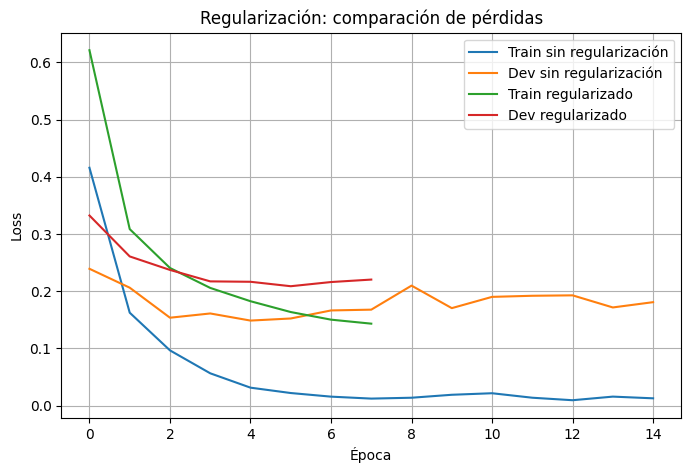

In [16]:
# COMPARACIÓN DE LAS CURVAS DE REGULARIZACIÓN
# Se muestran las pérdidas de entrenamiento y desarrollo de ambos modelos.
# Una brecha creciente entre train loss y dev loss puede indicar sobreajuste.
# La comparación permite observar si L2, Dropout y EarlyStopping ayudan a generalizar mejor.

plt.figure(figsize=(8, 5))

plt.plot(hist_sin_reg.history["loss"], label="Train sin regularización")

plt.plot(hist_sin_reg.history["val_loss"], label="Dev sin regularización")

plt.plot(hist_reg.history["loss"], label="Train regularizado")

plt.plot(hist_reg.history["val_loss"], label="Dev regularizado")

plt.xlabel("Época")

plt.ylabel("Loss")

plt.title("Regularización: comparación de pérdidas")

plt.legend()

plt.grid(True)

plt.show()

In [17]:
# EVALUACIÓN EN EL CONJUNTO DE DESARROLLO
# Se calculan loss y accuracy del modelo sin regularización y del regularizado.
# Los resultados permiten comparar el desempeño de ambos enfoques fuera de los datos usados para ajustar los pesos.

dev_sin_reg = modelo_sin_reg.evaluate(x_dev, y_dev, verbose=0)

dev_reg = modelo_reg.evaluate(x_dev, y_dev, verbose=0)



print("Sin regularización - dev loss/accuracy:", dev_sin_reg)

print("Regularizado      - dev loss/accuracy:", dev_reg)



Sin regularización - dev loss/accuracy: [0.18088938295841217, 0.9659166932106018]
Regularizado      - dev loss/accuracy: [0.2087736278772354, 0.9648333191871643]


In [18]:
# GENERACIÓN DE PREDICCIONES
# El modelo devuelve una distribución de probabilidades para cada una de las 10 clases.
# np.argmax selecciona la clase con mayor probabilidad para cada imagen.
# Se muestran algunas predicciones y sus clases reales para verificar el comportamiento.

probabilidades_test = modelo_reg.predict(x_test, verbose=0)

y_pred = np.argmax(probabilidades_test, axis=1)



print("Primeras predicciones:", y_pred[:20])

print("Primeras clases reales:", y_test[:20])

Primeras predicciones: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
Primeras clases reales: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [19]:
# CÁLCULO DE MÉTRICAS DE CLASIFICACIÓN
# Accuracy mide la proporción total de predicciones correctas.
# Precision macro calcula la precisión por clase y luego obtiene su promedio.
# Recall macro calcula la sensibilidad por clase y luego obtiene su promedio.
# F1 macro combina precision y recall por clase mediante la media armónica.
# zero_division=0 evita errores si alguna clase no tiene predicciones válidas.

accuracy = accuracy_score(y_test, y_pred)

precision_macro = precision_score(

    y_test, y_pred, average="macro", zero_division=0

)

recall_macro = recall_score(

    y_test, y_pred, average="macro", zero_division=0

)

f1_macro = f1_score(

    y_test, y_pred, average="macro", zero_division=0

)



print("Accuracy:", round(accuracy, 4))

print("Precision macro:", round(precision_macro, 4))

print("Recall macro:", round(recall_macro, 4))

print("F1 macro:", round(f1_macro, 4))

Accuracy: 0.9653
Precision macro: 0.9649
Recall macro: 0.9652
F1 macro: 0.965


In [20]:
# TABLA RESUMEN DE MÉTRICAS
# Se organizan las métricas calculadas en un DataFrame.
# Esto facilita presentar y comparar los principales indicadores del modelo.

metricas = pd.DataFrame({

    "metrica": ["Accuracy", "Precision macro", "Recall macro", "F1 macro"],

    "resultado": [accuracy, precision_macro, recall_macro, f1_macro]

})



display(metricas)

,metrica,resultado
0,Accuracy,0.965300
1,Precision macro,0.964883
2,Recall macro,0.965228
3,F1 macro,0.964962


In [21]:
# INFORME DETALLADO DE CLASIFICACIÓN
# classification_report presenta precision, recall y F1 para cada dígito.
# También muestra promedios y soporte de cada clase.
# digits=4 establece cuatro decimales en el resultado.

print(

    classification_report(

        y_test, y_pred,

        digits=4,

        zero_division=0

    )

)

              precision    recall  f1-score   support

           0     0.9642    0.9898    0.9768       980
           1     0.9884    0.9797    0.9841      1135
           2     0.9770    0.9486    0.9626      1032
           3     0.9608    0.9713    0.9660      1010
           4     0.9579    0.9735    0.9657       982
           5     0.9534    0.9630    0.9582       892
           6     0.9636    0.9666    0.9651       958
           7     0.9715    0.9601    0.9658      1028
           8     0.9417    0.9620    0.9518       974
           9     0.9703    0.9376    0.9536      1009

    accuracy                         0.9653     10000
   macro avg     0.9649    0.9652    0.9650     10000
weighted avg     0.9655    0.9653    0.9653     10000



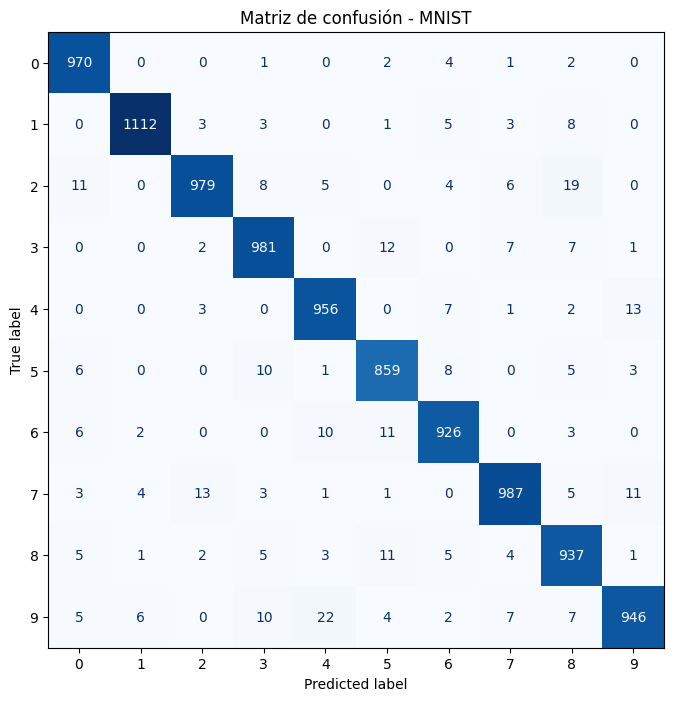

In [22]:
# MATRIZ DE CONFUSIÓN
# La matriz indica cuántas veces cada clase real fue predicha como cada clase.
# Las filas representan las clases reales y las columnas las clases predichas.
# La diagonal principal contiene los aciertos; los valores fuera de ella son errores.

cm = confusion_matrix(y_test, y_pred)



fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=np.arange(10)

)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Matriz de confusión - MNIST")

plt.show()

In [23]:
# IDENTIFICACIÓN DE LA CONFUSIÓN MÁS FRECUENTE
# Se copia la matriz para no modificar la original.
# Se pone la diagonal en cero para ignorar los aciertos.
# np.argmax encuentra el par de clases con mayor número de errores.
# Se informa qué dígito real fue confundido con qué predicción y cuántas veces ocurrió.

cm_errores = cm.copy()

np.fill_diagonal(cm_errores, 0)



real_confundido, predicho_como = np.unravel_index(

    np.argmax(cm_errores),

    cm_errores.shape

)



cantidad = cm_errores[real_confundido, predicho_como]



print(

    f"La confusión más frecuente fue: "

    f"{real_confundido} clasificado como {predicho_como} "

    f"({cantidad} veces)"

)

La confusión más frecuente fue: 9 clasificado como 4 (22 veces)


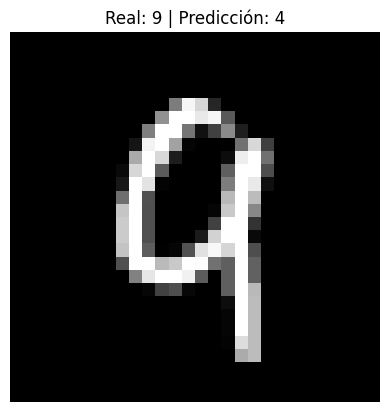

In [24]:
# VISUALIZACIÓN DE UN EJEMPLO DE ERROR
# Se localiza la primera imagen que corresponde a la confusión más frecuente.
# Si existe al menos un ejemplo, se muestra la imagen en escala de grises.
# El título permite comparar la etiqueta real con la predicción del modelo.

indices = np.where(

    (y_test == real_confundido) &

    (y_pred == predicho_como)

)[0]



if len(indices) > 0:

    idx = indices[0]

    plt.imshow(x_test[idx], cmap="gray")

    plt.title(

        f"Real: {y_test[idx]} | Predicción: {y_pred[idx]}"

    )

    plt.axis("off")

    plt.show()



In [25]:
# MODELO PEQUEÑO
# Se crea una red mucho más pequeña con solamente 16 neuronas en la capa oculta.
# El experimento sirve para evaluar el efecto de reducir la capacidad del modelo.
# Se entrena durante solo 2 épocas para obtener una referencia rápida de desempeño.

modelo_pequeno = keras.Sequential([

    layers.Input(shape=(28, 28)),

    layers.Flatten(),

    layers.Dense(16, activation="relu"),

    layers.Dense(10, activation="softmax")

])



modelo_pequeno.compile(

    optimizer=keras.optimizers.Adam(0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)



hist_pequeno = modelo_pequeno.fit(

    x_train, y_train,

    validation_data=(x_dev, y_dev),

    epochs=2,

    batch_size=64,

    verbose=0

)

In [26]:
# FUNCIÓN PARA DIAGNOSTICAR LA BRECHA ENTRE TRAIN Y DEV
# La función obtiene el accuracy final de entrenamiento y validación.
# La brecha train-dev mide cuánto mejor se comporta el modelo sobre los datos de entrenamiento.
# Una brecha grande puede ser una señal de sobreajuste.

def resumen_historia(nombre, historia):

    train_acc = historia.history["accuracy"][-1]

    dev_acc = historia.history["val_accuracy"][-1]

    return {

        "modelo": nombre,

        "train_accuracy": train_acc,

        "dev_accuracy": dev_acc,

        "brecha_train_dev": train_acc - dev_acc

    }



tabla_diagnostico = pd.DataFrame([

    resumen_historia("Pequeño", hist_pequeno),

    resumen_historia("Sin regularización", hist_sin_reg),

    resumen_historia("Regularizado", hist_reg)

])



display(tabla_diagnostico)

,modelo,train_accuracy,dev_accuracy,brecha_train_dev
0,Pequeño,0.914312,0.914583,-0.000271
1,Sin regularización,0.995667,0.965917,0.029750
2,Regularizado,0.980000,0.962250,0.017750


In [27]:
# IMPLEMENTACIÓN DE UNA RED EQUIVALENTE EN PYTORCH
# Se importan PyTorch, las capas de redes neuronales y los optimizadores.
# La clase RedMNISTRegularizada define una red con Flatten, una capa densa,
# ReLU, Dropout y una capa final de 10 salidas.
# CrossEntropyLoss calcula la pérdida para clasificación multiclase.
# Adam actualiza los pesos y weight_decay introduce penalización L2.
# En este bloque se construye e imprime el modelo; todavía no se ejecuta su entrenamiento.

import torch

import torch.nn as nn

import torch.optim as optim



class RedMNISTRegularizada(nn.Module):

    def __init__(self):

        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 256)

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.30)

        self.fc2 = nn.Linear(256, 10)



    def forward(self, x):

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        return self.fc2(x)



modelo_torch = RedMNISTRegularizada()

criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(

    modelo_torch.parameters(),

    lr=0.001,

    weight_decay=1e-4

)



print(modelo_torch)

RedMNISTRegularizada(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
